# IBM HR Analytics Employee Attrition Analysis

## 1.Business Objective

The objective of this project is to analyze employee data to identify factors influencing employee attrition and provide business recommendations to improve employee retention.

---

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

**Dataset**

IBM HR Analytics Employee Attrition Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 2.Dataset Overview


The IBM HR Analytics Employee Attrition dataset contains information about employees, including demographic details, job-related attributes, compensation, work experience, and attrition status.

The dataset consists of **1,470 employee records** and **35 features**, with a combination of numerical and categorical variables.

The primary objective of this analysis is to understand employee characteristics, identify patterns associated with attrition, and provide business insights that can help improve employee retention.

# 3.Data Understanding

In [3]:

print(df.shape)

(1470, 35)


### Observation

The dataset contains 1,470 employee records and 35 features.

This indicates that the dataset is of moderate size and is suitable for exploratory data analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Observation

The dataset contains both numerical and categorical variables.

All columns have 1,470 non-null values, indicating there are no missing values.

In [5]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

### Observation

The descriptive statistics provide a summary of the numerical variables in the dataset.

The average employee age is around 37 years, while monthly income shows considerable variation across employees, indicating differences in job levels and experience.

In [6]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [7]:
df.select_dtypes(include="object").columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

### Observation

The dataset contains categorical variables representing employee demographics, job information, and employment status.

These variables will be used extensively in the exploratory analysis.

In [8]:
df.select_dtypes(include="number").columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

### Observation

The numerical variables include employee age, salary, work experience, performance ratings, and tenure-related features.

These variables will be analyzed to identify patterns associated with employee attrition.

# 4.Data Quality Check

In [9]:

print(df.isnull().sum())


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
print(df.duplicated().sum())

0


In [11]:
print(df.nunique())

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [12]:
print(df[df["YearsAtCompany"] > df["TotalWorkingYears"]])

Empty DataFrame
Columns: [Age, Attrition, BusinessTravel, DailyRate, Department, DistanceFromHome, Education, EducationField, EmployeeCount, EmployeeNumber, EnvironmentSatisfaction, Gender, HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction, MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked, Over18, OverTime, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StandardHours, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager]
Index: []

[0 rows x 35 columns]


### Observation

No invalid records were found where an employee's years at the company exceeded their total working experience.

This confirms the logical consistency of the experience-related variables.

In [13]:
print(df[df["YearsInCurrentRole"] > df["YearsAtCompany"]])

Empty DataFrame
Columns: [Age, Attrition, BusinessTravel, DailyRate, Department, DistanceFromHome, Education, EducationField, EmployeeCount, EmployeeNumber, EnvironmentSatisfaction, Gender, HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction, MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked, Over18, OverTime, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StandardHours, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager]
Index: []

[0 rows x 35 columns]


### Observation

No employee has spent more years in their current role than their total years at the company.

The tenure-related variables are logically consistent.

# 5. Data Cleaning

The dataset required minimal preprocessing.

- No missing values were detected.
- No duplicate records were found.
- Logical validation confirmed that the tenure-related variables are consistent.
- Data types were appropriate for analysis.

Therefore, the dataset was ready for exploratory data analysis without requiring significant cleaning.

# Key Variables Used in This Analysis

| Column             | Description |
|--------            |-------------|
| Attrition          | Whether the employee left the company |
| Age                | Employee age |
| Department         | Department where the employee works |
| JobRole            | Employee job role |
| MonthlyIncome      | Monthly salary |
| TotalWorkingYears  | Total work experience |
| YearsAtCompany     | Years spent in the current company |
| JobLevel           | Employee job level |

# 6. Exploratory Data Analysis (EDA)

The objective of the exploratory data analysis is to identify patterns, trends, and relationships within the workforce that may influence employee attrition.

The analysis is organized into the following sections:

- Workforce Overview
- Attrition Analysis
- Employee Demographics
- Compensation Analysis
- Experience Analysis
- Correlation Analysis

## 6.1 Workforce Overview

### Business Question 1

How many employees are included in the dataset?

In [14]:
total_employees=len(df)

print(f"Total Employees : {total_employees}")

Total Employees : 1470


### Observation

The dataset contains **1,470 employees**, representing the workforce available for analysis.

### Business Insight

Understanding the workforce size provides context for interpreting employee distributions and attrition rates throughout the analysis.

### Business Question 2

How are employees distributed across different departments?

In [15]:
department_count=df["Department"].value_counts()

department_count

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

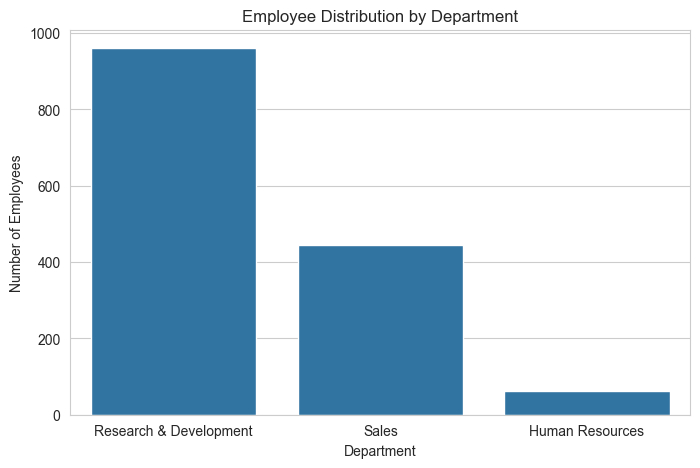

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    order=department_count.index
)

plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

### Observation

Research & Development has the largest number of employees, followed by Sales, while Human Resources has the smallest workforce.

### Business Insight

Departments with larger workforces naturally contribute more employees to the organization. Later analyses should compare attrition using **rates rather than counts** to avoid misleading conclusions caused by department size.

### Business Question 3

What is the gender distribution of employees?

In [17]:
gender_count=df["Gender"].value_counts()

gender_count

Gender
Male      882
Female    588
Name: count, dtype: int64

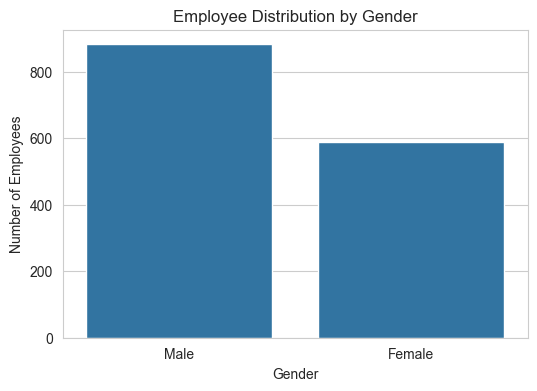

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
  data=df,
  x="Gender",
  order=gender_count.index
)

plt.title("Employee Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.show()

### Observation

The workforce consists of both male and female employees, with males representing a larger proportion of the dataset.

### Business Insight

Since the workforce is not evenly distributed by gender, attrition should later be eveluated using **attrition rates** instead of employee counts.

### Business Question 4

How are employees distributed across different marital status categories?

In [19]:
marital_count=df["MaritalStatus"].value_counts()

marital_count

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

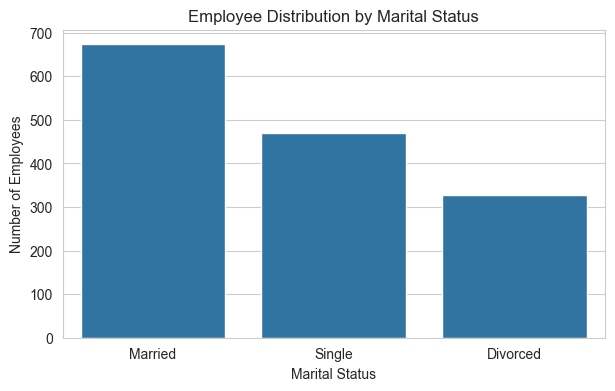

In [20]:
plt.figure(figsize=(7,4))

sns.countplot(
  data=df,
  x="MaritalStatus",
  order=marital_count.index
)

plt.title("Employee Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Employees")

plt.show()

### Observation 

The dataset contains employees who are Married, Single and Divorced, with Married employees forming the largest group.

### Business Insight

Marital status may influence employee retention. Later analyses will investigate whether attrition differs across these groups.

### Business Question 5

How are employees distributed across different job roles?

In [21]:
jobrole_count=df["JobRole"].value_counts()

jobrole_count

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

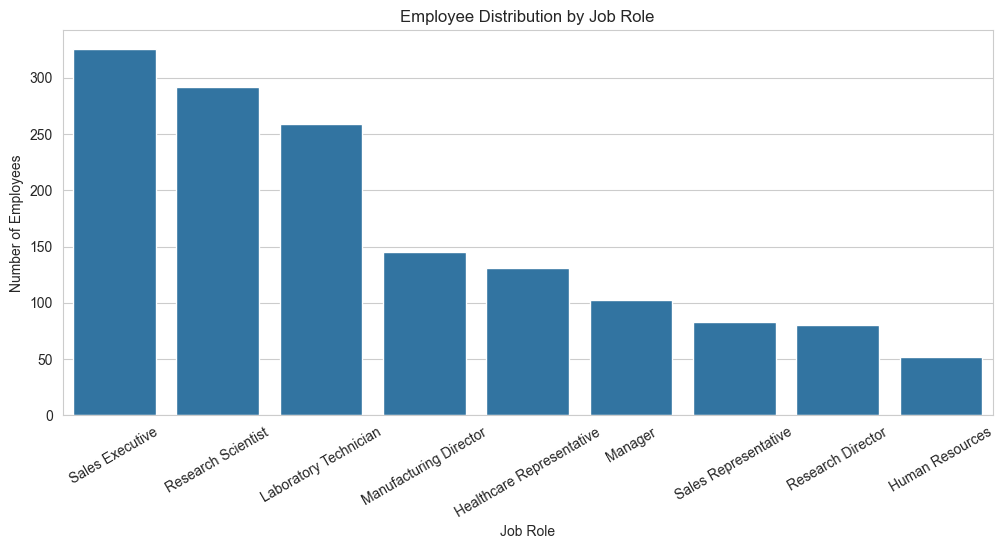

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(
  data=df,
  x="JobRole",
  order=jobrole_count.index
)

plt.title("Employee Distribution by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")

plt.xticks(rotation=30)

plt.show()

### Observation

Employee counts vary considerably across job roles, with Sales Executive has the highest workforce among all the job roles and Human Resources has lowest workforce among all the job roles.

### Business Insight

Difference in workforce size across job roles should be considered when evaluating employee turnover. Larger job roles may naturally record more employees exits, making attrition rates more informative than raw counts.

# 6.2 Attrition Analysis

This section examines employee attrition across different categories to identify high-risk groups and potential factors associated with employee turnover.

### Business Question 1

What is the overall employee attrition rate?

In [23]:
attrition_count=df["Attrition"].value_counts()

attrition_rate=(
  df["Attrition"]
  .value_counts(normalize=True)
  .mul(100)
  .round(2)
)

print(attrition_count)
print(attrition_rate)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


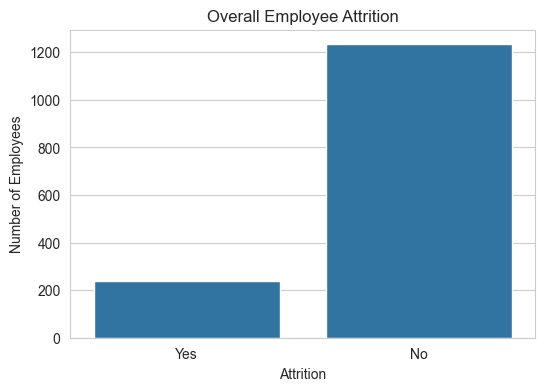

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Attrition")

plt.title("Overall Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

### Observation 

The majority of employees remained in the company, while a smaller proportion left. The overall attrition rate is approximately **16%**, indicating that most employees stayes with the organization.

### Business Insight

Although the overall attrition is relatively low, identifying the groups with higher attrition is important for improving employee retention.

### Business Question 2

Which department has the highest employee attrition rate?

In [25]:
department_attrition=(
  df.groupby("Department")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .round(2)
    .sort_values(ascending=False)
)

department_attrition

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

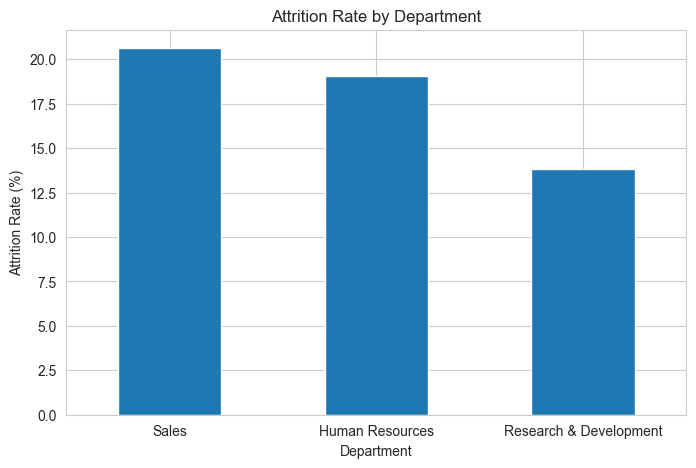

In [26]:
plt.figure(figsize=(8,5))

department_attrition.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Observation

The Sales department has the highest attrition rate, while the Research &Development department has the lowest attrition rate. However, the differnces in attrition rates across departments are relatively small.

### Business Insight

Although the Sales department has the highest attrition rate, the difference compared to other departments is not substantial. Further analysis is required to determine whether factors such as investigation business travel, overtime, workload, job satisfaction or work-life balance contribute to the higher employee turnover in the department.

### Business Question 3

Which job role has highest attrition rate?

In [27]:
jobrole_attrition = (
  df.groupby("JobRole")["Attrition"]
   .apply(lambda x: (x=="Yes").mean()*100)
   .round(2)
   .sort_values(ascending=False)
)

jobrole_attrition

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

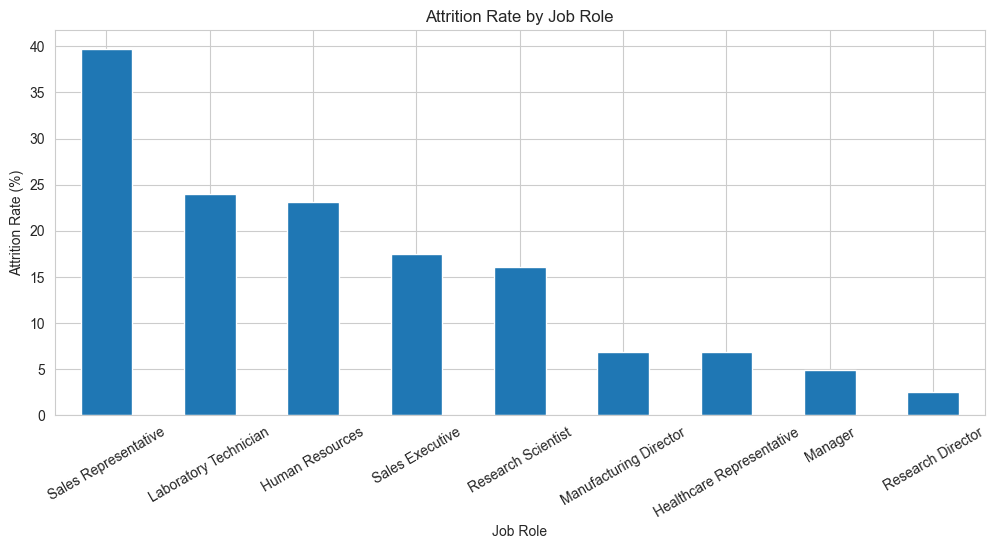

In [28]:
plt.figure(figsize=(12,5))

jobrole_attrition.plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=30)

plt.show()

### Observation

Sales representatives have the highest attrition rate among all the job roles, while Research Director have the lowest attrition rate.

### Business Insight

The high attrition rate among Sales Representative suggests that this job role may face greater retenyion challenges than others. Further analysis is required to determine whether factors such as overtime, business travel, workload, job satisfaction, work-life balance, compensation, or career growth opportunities contribute to the higher employee turnover.

### Business Question 4

Does attrition differ by gender?

In [29]:
gender_attrition = (
  df.groupby("Gender")["Attrition"]
  .apply(lambda x: (x=="Yes").mean()*100)
  .round(2)
)

gender_attrition

Gender
Female    14.80
Male      17.01
Name: Attrition, dtype: float64

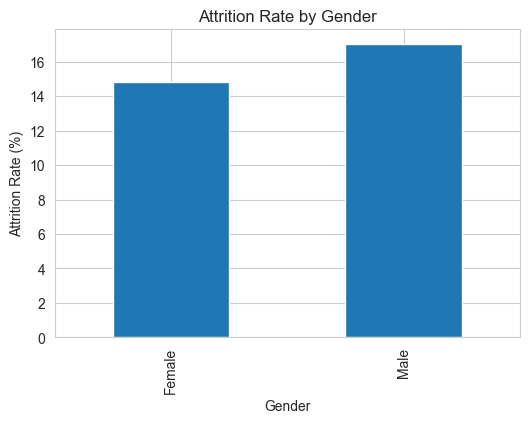

In [30]:
plt.figure(figsize=(6,4))

gender_attrition.plot(kind="bar")

plt.title("Attrition Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation

Male employees have slightly higher attrition rate than female employees. however the difference in attrition rates between two groups is relatively small.

### Business Insight

Although the Male employees have a slightly highest attrition rate, the difference compared to female employees are not substantial. This sugests that gender alone may not be a primary factor influencing employee attrition. Further analysis is needed to determine whether factors such as overtime, work-life balance, incentives, compensation, workload, job satisfaction, or career growth opportunities contribute to the observed difference.

### Business Question 5

Which marital status group has the highest attrition rate?

In [31]:
marital_attrition=(
  df.groupby("MaritalStatus")["Attrition"]
    .apply(lambda x: (x=="Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

marital_attrition

MaritalStatus
Single      25.53
Married     12.48
Divorced    10.09
Name: Attrition, dtype: float64

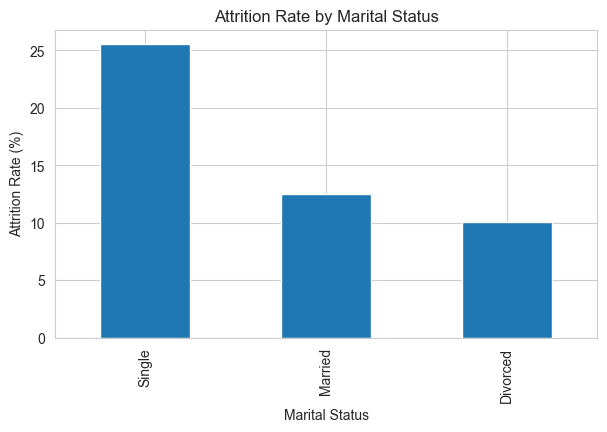

In [32]:
plt.figure(figsize=(7,4))

marital_attrition.plot(kind="bar")

plt.title("Attrition Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation

Single Employees have the highest attrition rate, while divorced employees have the lowest attrition rate among the three marital status groups.

### Business Insight

The higher attrition rate among the single employees suggests that this group may be more likely to leave the organization than married and divorced employees. However, marital status does not alone explain employee turnover. Further analysis is required to determine whether factors such as overtime, workload, career growth opportunities, job satisfaction, compensation, or work-life balance contribute to higher attrition rate observed among the single employees.

### Business Question 6

Does working overtime appear to be associated with higher employee attrition?

In [33]:
overtime_attrition = (
  df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean()*100)
    .round(2)
)

overtime_attrition

OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64

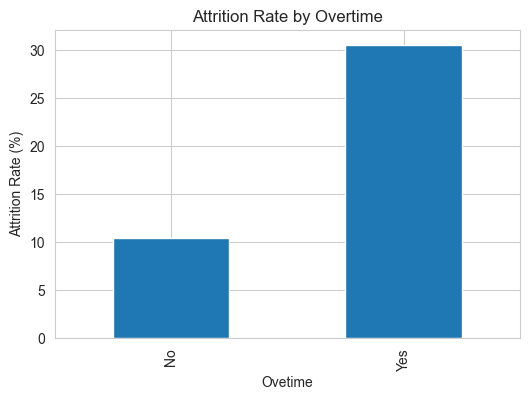

In [34]:
plt.figure(figsize=(6,4))

overtime_attrition.plot(kind="bar")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Ovetime")
plt.ylabel("Attrition Rate (%)")

plt.show()


### Observation

Employees who work overtime have a significantly highest attrition rate than employees who do not work overtime. However, attrition is also observed who do not work overtime.

### Business Insight

The substantially higher attrition rate among employees who work overtime suggests that overtime may be associated with employee turnover. However, since attrition also occurs among employees who do not work overtime, overtime alone does not fully explain employee attrition. Further analysis is needed to determine whether factors such as workload, job satisfaction, work-life balance, compensation, or career growth opportunities also contribute to employee turnover

### Business Question 7

Which department–job role combination has the highest attrition rate?

In [35]:
dept_job_attrition=(
  df.groupby(["Department","JobRole"])["Attrition"]
    .apply(lambda x: (x=="Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

dept_job_attrition

Department              JobRole                  
Sales                   Sales Representative         39.76
Research & Development  Laboratory Technician        23.94
Human Resources         Human Resources              23.08
Sales                   Sales Executive              17.48
Research & Development  Research Scientist           16.10
                        Manufacturing Director        6.90
                        Healthcare Representative     6.87
                        Manager                       5.56
Sales                   Manager                       5.41
Research & Development  Research Director             2.50
Human Resources         Manager                       0.00
Name: Attrition, dtype: float64

In [36]:
dept_job_attrition.head(10)

Department              JobRole                  
Sales                   Sales Representative         39.76
Research & Development  Laboratory Technician        23.94
Human Resources         Human Resources              23.08
Sales                   Sales Executive              17.48
Research & Development  Research Scientist           16.10
                        Manufacturing Director        6.90
                        Healthcare Representative     6.87
                        Manager                       5.56
Sales                   Manager                       5.41
Research & Development  Research Director             2.50
Name: Attrition, dtype: float64

### Observation

Sales Representatives in the Sales department have the highest attrition rate among all department-job role combination, whereas Managers in Human Resources department have no recorded attrition in the dataset.

### Business Insight

The high attrition rate among Sales Representatives in the Sales department suggests that this group may face greater retention challenges than other department-job role combination. Further analysis is needed to determine whether factors such as overtime, business travel, workload, job satisfaction, compensation, or work-life balance contribute to the higher employee turnover.


## 6.3 Employee Demographics Analysis


### Business Question 1

What is the age distribution of employees?

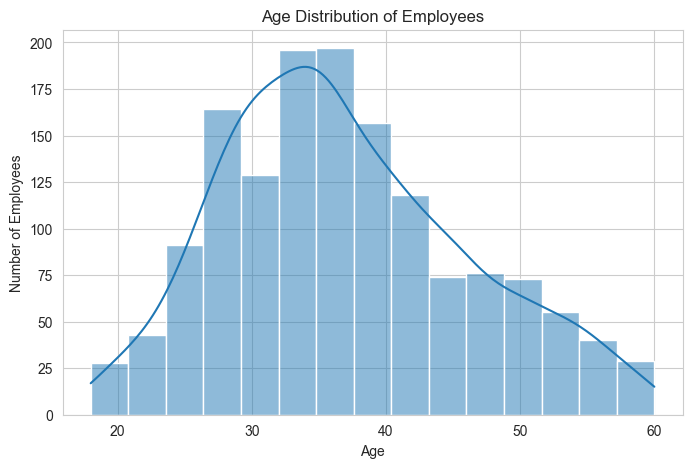

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"],bins=15,kde=True)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

### Observation

The workforce consists primarily of employees in the early to mid-career age groups, with fewer employees at the younger and older ends of the age distribution.

### Business Insight

Understanding the workforce age distribution helps identify the dominant employee age group and provides context for analyzing attrition pattern across different age ranges.

### Business Insight

Which age groupp has the highest attrition rate?

In [38]:
bins=[18, 25, 35, 45, 55, 65]
labels=["18-25", "26-35", "36-45", "46-55", "56-65"]

df["AgeGroup"] = pd.cut(df["Age"],bins=bins,labels=labels)

In [39]:
age_attrition=(
  df.groupby("AgeGroup")["Attrition"]
    .apply(lambda x: (x == "Yes").mean()*100)
    .round(2)
)

age_attrition

C:\Users\nandh\AppData\Local\Temp\ipykernel_14472\1269332893.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Attrition"]


AgeGroup
18-25    34.78
26-35    19.14
36-45     9.19
46-55    11.50
56-65    17.02
Name: Attrition, dtype: float64

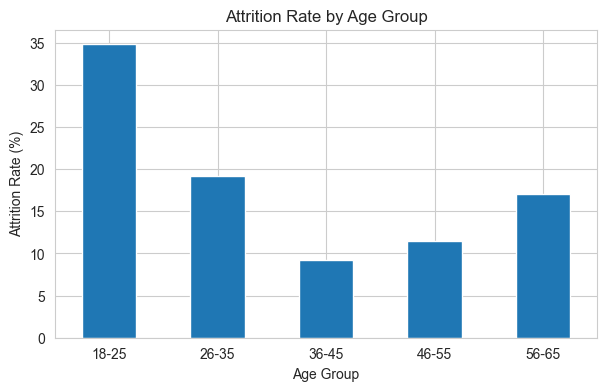

In [40]:
plt.figure(figsize=(7,4))

age_attrition.plot(kind="bar")

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Observation 

Employees in the **18-25** age group have the highest attrition rate among all age groups,while employess in the **36-45** age group have the lowest attrition rate.

### Business Insight

The high attrition rate among employees aged **18–25** suggests that younger employees may be more likely to leave the organization than employees in other age groups. However, age alone does not explain employee turnover. Further analysis is needed to determine whether factors such as overtime, compensation, workload, work-life balance, job satisfaction, or career growth opportunities are associated with the higher attrition observed in this age group.

### Business Question 3

What is the distribution of employees across different education levels?

In [41]:
education_count=df["Education"].value_counts().sort_index()

education_count

Education
1    170
2    282
3    572
4    398
5     48
Name: count, dtype: int64

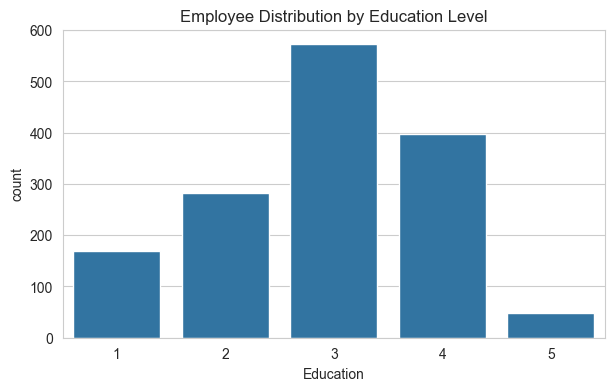

In [42]:
plt.figure(figsize=(7,4))

sns.countplot(data=df,x="Education")

plt.title("Employee Distribution by Education Level")

plt.show()

### Observation

Educational Level **3** has the highest number of employees in the organization, followed by Educational Level **4**. In contrast, Educational Level **5** has the fewest employees.

### Business Insight

The workforce is primarily concentrated on Education Levels **3** and **4**, indicating that most employees share similar educational qualification. While analysis describes the educational composition of the workforce, it does not indicate whether education level influences employee attrition. Further analysis of attrition rates across different education levels is required to determine whether employee turnover varies by educational qualification.

### Business Question 4

Which education field has the highest attrition rate?

In [43]:
educational_field_attrition=(
  df.groupby("EducationField")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .round(2)
    .sort_values(ascending=False)
)

educational_field_attrition

EducationField
Human Resources     25.93
Technical Degree    24.24
Marketing           22.01
Life Sciences       14.69
Medical             13.58
Other               13.41
Name: Attrition, dtype: float64

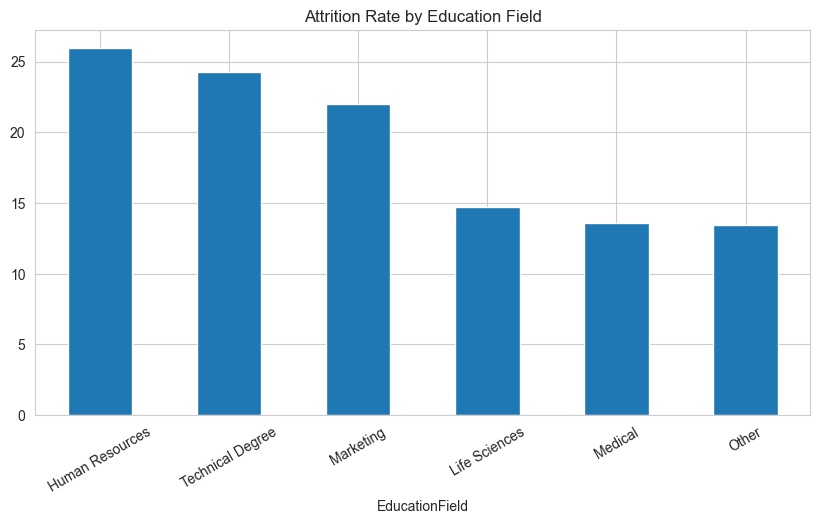

In [44]:
plt.figure(figsize=(10,5))

educational_field_attrition.plot(kind="bar")

plt.title("Attrition Rate by Education Field")

plt.xticks(rotation=30)

plt.show()

### Observation 
 
Employees with a **Human Resources** educational field have the highest attrition, while employees with a  **Medical** and **Other** have the lowest attrition

### Business Insight

The higher attrition rate among employees with a **Human Resources** education field suggests that this group may experience greater employee turnover than those from other educational backgrounds. However, education field alone does not explain attrition. Further analysis is needed to determine whether factors such as overtime, compensation, workload, work-life balance, job satisfaction, career growth opportunities, or job roles are associated with the higher attrition observed among these employees.

### Business Question 5

Does employee attrition vary across different education levels?

In [45]:
educational_attrition=(
  df.groupby("Education")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .round(2)
)

educational_attrition

Education
1    18.24
2    15.60
3    17.31
4    14.57
5    10.42
Name: Attrition, dtype: float64

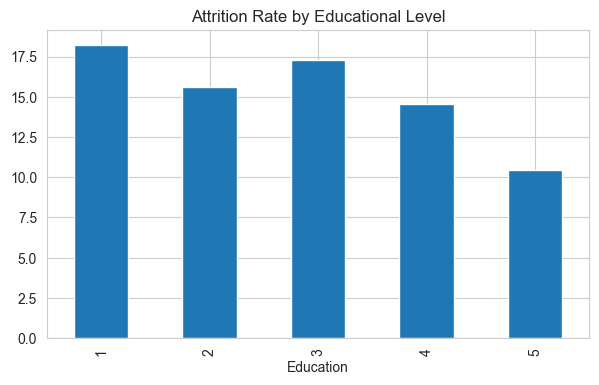

In [46]:
plt.figure(figsize=(7,4))

educational_attrition.plot(kind="bar")

plt.title("Attrition Rate by Educational Level")

plt.show()

### Observation

Employees with **Educational Level 1** have the highest attrition rate, followed by those with  **Educational Level 3**. In contrast, employees with **Educational Level 5** have lowest attrition rate.

### Business Insight

The highest attrition rate among employees with **Educational Level 1** suggests what employees with lower educational qualifications may be more likely to leave the organization than those with higher educational levels. However, educational level alone does nit explain employee attrition. Further analysis is needed to determine whether factors such as compensation, overtime, workload, work-life balance, job satisfaction, career growth opportunities,or job roles are associated with the higher attrition observed among the employees.

## Compensation Analysis

### Business Question 1

How are employees distributed across different monthly income levels?

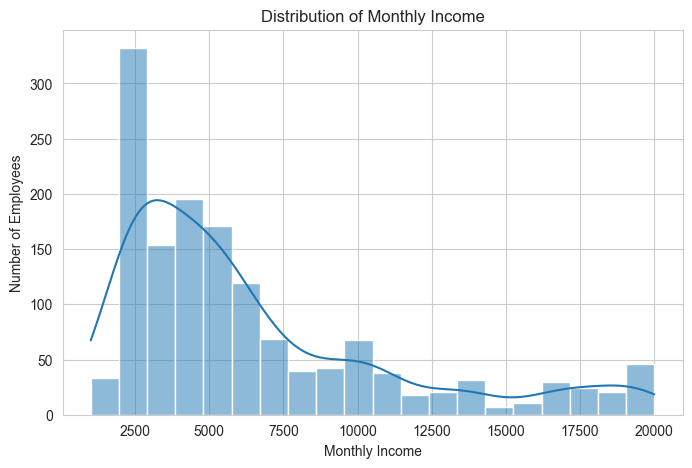

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"],bins=20,kde=True)

plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.show()

### Observation 

The distribution of monthly income is right-skewed, with most employees earning lower to moderate monthly incomes. Only a relatively small number of employees receive higher monthly incomes.

### Business Insight

The organization's workforce is primarily concentrated in the lower to moderate monthly income ranges, while relatively few employees earn higher salaries. This analysis provides an overview of the company's salary distribution but does not indicate whether income influences employee attrition. Further analysis of attrition rates across different monthly income groups is required to determine whether compensation is associated with employee turnover.

### Business Question 2

Does employee attrition vary across different monthly income groups?

In [48]:
income_group=pd.qcut(
  df["MonthlyIncome"],
  q=4,
  labels=["Low","Medium","High","Very High"]
)

df["IncomeGroup"]=income_group

In [49]:
income_attrition=(
  df.groupby("IncomeGroup")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .round(2)
)

income_attrition

C:\Users\nandh\AppData\Local\Temp\ipykernel_14472\3389801263.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("IncomeGroup")["Attrition"]


IncomeGroup
Low          29.27
Medium       14.21
High         10.63
Very High    10.33
Name: Attrition, dtype: float64

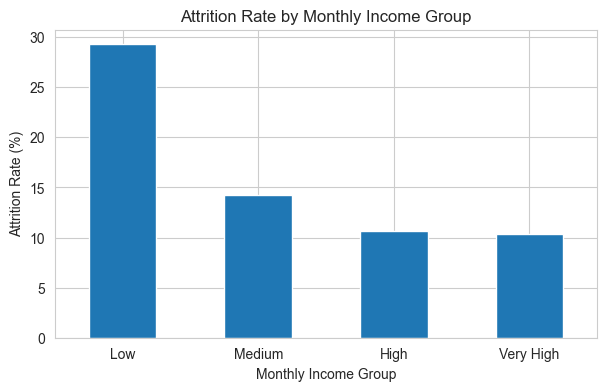

In [50]:
plt.figure(figsize=(7,4))

income_attrition.plot(kind="bar")

plt.title("Attrition Rate by Monthly Income Group")
plt.xlabel("Monthly Income Group")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Observation

Employees in the **Low Monthly Income** group have the highest attrition rate among all income groups. In contrast, employees in the **High** and **Very High Monthly Income** group have the lowest attrition rate.

### Business Insight

The higher attrition rate among employees in the **Low Monthly Income** group suggests that lower-paid employees may be more likely to leave the organization than those in higher income groups. However, monthly income alone does not fully explain employee attrition. Further analysis is needed to determine whether factors such as workload, overtime, work-life balance, job satisfaction, or career growth opportunities are associated with the higher employee turnover observed in this group.

### Business Question 3

Does employee attrition vary by stock option level?

In [51]:
stock_attrition=(
  df.groupby("StockOptionLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean()*100)
    .round(2)
)

stock_attrition

StockOptionLevel
0    24.41
1     9.40
2     7.59
3    17.65
Name: Attrition, dtype: float64

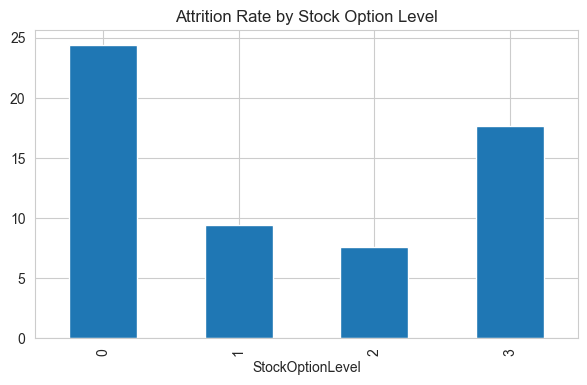

In [52]:
plt.figure(figsize=(7,4))

stock_attrition.plot(kind="bar")

plt.title("Attrition Rate by Stock Option Level")

plt.show()

### Observation

Employee with **Stock Option Level 0** have the highest attrition rate among all stock option levels. In contrast, employees with **Stock Option Levels 2 and 1** have the lowest attrition rate. 

### Business Insight

The highest attrition rate among employees in the **Stock Option Level 0** suggests that employees who do not receive stock options may be more likely to leave the organization than those with stock-based benefits.However, stock option level alone does not fully explain employee attrition. Further analysis is neede to determine whether factors such as compensation, workload, overtime, work-life balance, job satisfaction, or career growth opportunities are assotiated with the highest employee turnover observed among these employees.

### Business Question 4

Is employee attrition associated with the percentage salary hike received?

In [53]:
salary_hike_attrition=(
  df.groupby("PercentSalaryHike")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .round(2)
)

salary_hike_attrition

PercentSalaryHike
11    19.52
12    16.67
13    16.27
14    11.94
15    17.82
16    17.95
17    17.07
18    14.61
19    11.84
20    12.73
21    10.42
22    21.43
23    21.43
24    28.57
25     5.56
Name: Attrition, dtype: float64

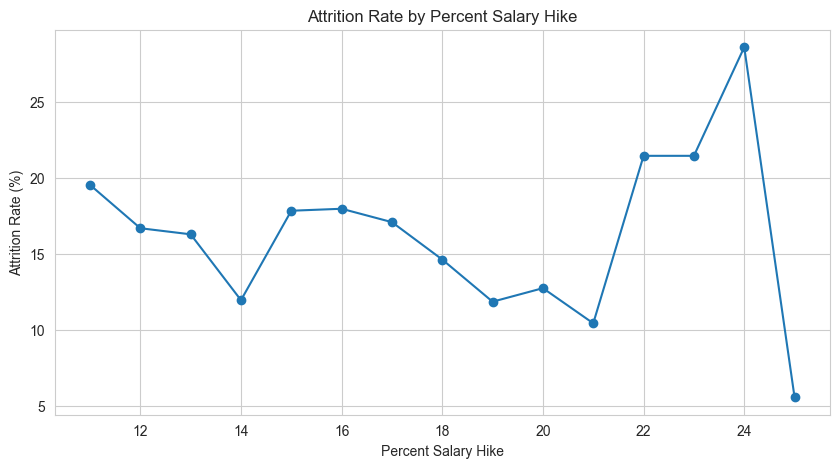

In [54]:
plt.figure(figsize=(10,5))

salary_hike_attrition.plot(marker="o")

plt.title("Attrition Rate by Percent Salary Hike")
plt.xlabel("Percent Salary Hike")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation

The attrition rate varies across different percent salary hike levels, with no consistent increasing or decreasing trend. Some salary hike percentages, such as **24%**, show relatively higher attrition rates, while others, such as **25%**, show much lower attrition rates.

### Business Insight

The variation in attrition rates across different salary hike percentages suggests that **percent salary hike alone does not appear to have a clear relationship with employee attrition**. The higher or lower attrition rates observed at certain salary hike levels should be interpreted with caution, as some groups may contain relatively few employees. Further analysis is needed to determine whether factors such as monthly income, stock option level, overtime, workload, job satisfaction, work-life balance, or career growth opportunities are associated with employee turnover.

## 6.5 Experience Analysis

### Business Question 1

What is the distribution of employees' total working experience?

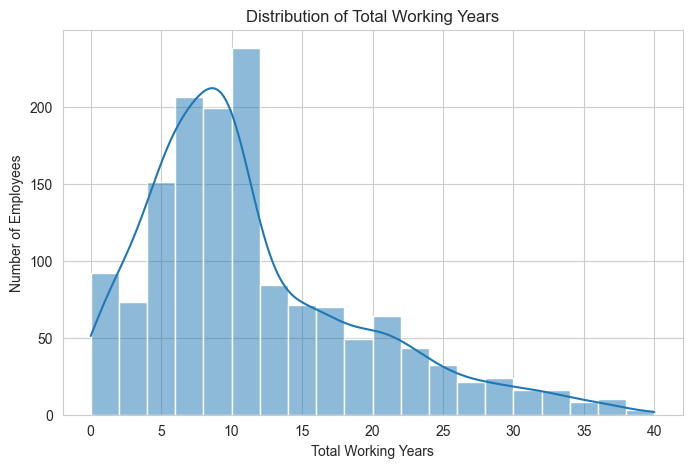

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalWorkingYears"],bins=20,kde=True)

plt.title("Distribution of Total Working Years")
plt.xlabel("Total Working Years")
plt.ylabel("Number of Employees")

plt.show()

### Observation

The distribution of total working years is right-skewed, with most employees having relatively few years of work experience. Only a  small proportion of employees have many years of work experience.

### Business Insight

The organization's workforce is primarily composed of employees with relatively few years of work experience, while a small proportion consists of highly experienced employees. This analysis provides an overview of the workforce's experience levels does not indicate whether work experience influence employee attrition. Further analysis of attrition rate across different experience levels is required to determine whether employee turnover varies with total working experience.

### Business Question 2

How does total working experience relate to monthly income?

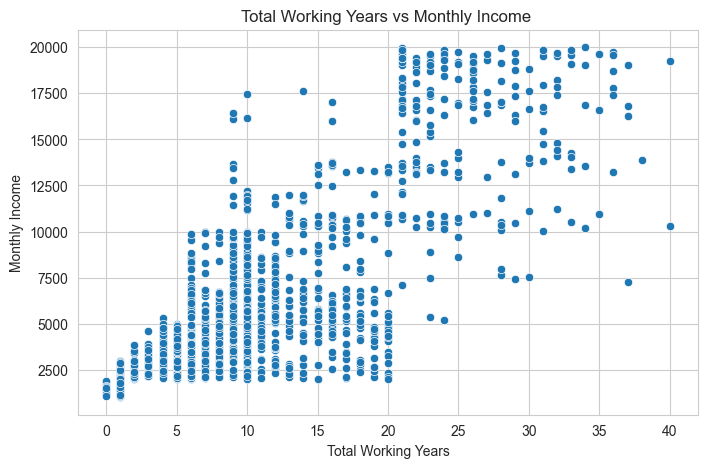

In [56]:
plt.figure(figsize=(8,5))

sns.scatterplot(
  data=df,
  x="TotalWorkingYears",
  y="MonthlyIncome"
)

plt.title("Total Working Years vs Monthly Income ")
plt.xlabel("Total Working Years")
plt.ylabel("Monthly Income")

plt.show()

### Observation

Monthly income generally increases as total working years increase. Although employees with similar levels of experience may earn different salaries, the overall trend indicates a positive relationship between work experience and monthly income.

### Business Insight

The positive relationship between total working years and monthly income suggests that employees with greater work experience generally receive higher salaries. However, salary differences among employees with similar experience indicate that other factors, such as job role, department, education level, or performance, may also influence compensation.

### Business Question 3

How are employees distributed based on their years of service at the company?

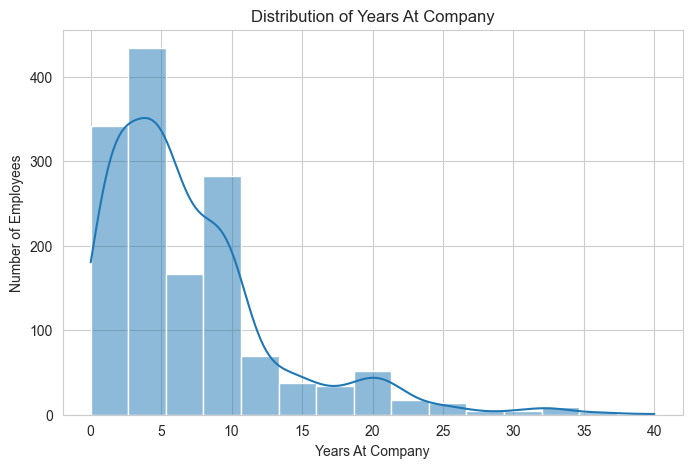

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(df["YearsAtCompany"],bins=15,kde=True)

plt.title("Distribution of Years At Company")
plt.xlabel("Years At Company")
plt.ylabel("Number of Employees")

plt.show()

### Observation

The distribution of years at the company is right-skewed, with most employees having relatively fewer years of service. Only a small proportion of employees have remained with the organization for many years.

### Business Insight

The organization's workforce is primarily composed of employees with relatively short organizational tenure, while fewer employees have long-term service. This analysis provides an overview of employee tenure but does not indicate whether employees are more likely to leave during the early stages of employment. Further analysis of attrition rates by years at the company is required to determine whether employee turnover is higher among employees with shorter tenure.

### Business Question 4

Does employee attrition vary with years spent at the company?

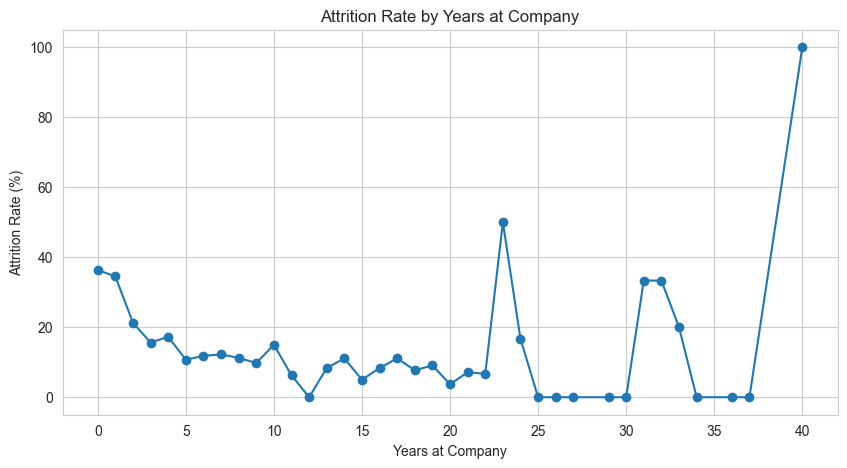

In [58]:
company_attrition=(
  df.groupby("YearsAtCompany")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
    .round(2)
)

company_attrition.plot(marker="o",figsize=(10,5))

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation

Employees with fewer years at the company generally have higher attrition rates than the employees with longer organizational tenure. Although attrition rates flucatuate at higher tenure levels , these variations should be interpreted with caution, as they may represent relatively smaller number of employees.

### Business Insight

The higher attrition rate among employees with shorter organizational tenure suggests that employees may be more likely to leave during the early stages of the employment. However, years at the company slone does not fully explain employee attrition. Further analysis is needed to determine whether factors such as career growth opportunities, compensation, workload, overtime, work-life balance, job satisfaction, or onboarding experience are associated with the higher employee turnover observed among employees with shorter tenure.

### Business Question 5

Is employee attrition associated with the number of years since the last promotion?

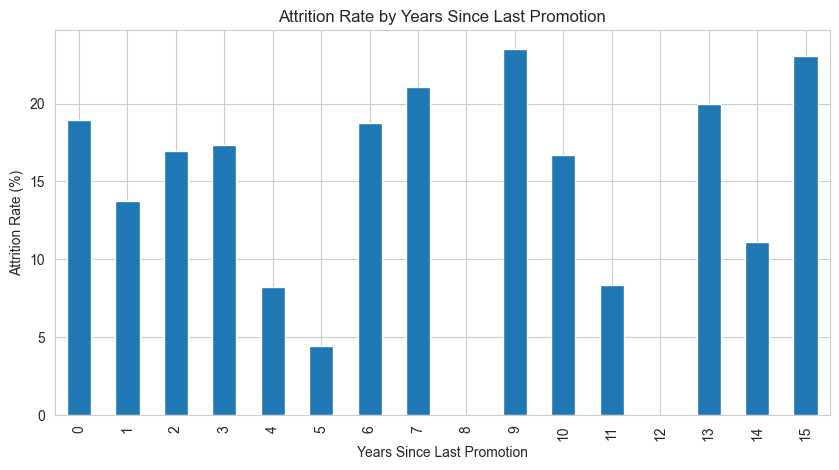

In [59]:
promotion_attrition = (
    df.groupby("YearsSinceLastPromotion")["Attrition"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

promotion_attrition.plot(kind="bar", figsize=(10,5))

plt.title("Attrition Rate by Years Since Last Promotion")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation

The attrition rate fluctuates considerably across different values of **Years Since Last Promotion**, with no consistent increasing or decreasing trend. Some promotion intervals exhibit relatively high attrition rates, while others show very low or no attrition.

### Business Insight

The variation in attrition rates across different values of **Years Since Last Promotion** suggests that the number of years since an employee's last promotion alone does not have a clear relationship with employee attrition. The fluctuations observed at certain promotion intervals should be interpreted with caution, as some groups may contain relatively few employees. Further analysis is needed to determine whether factors such as career growth opportunities, job satisfaction, compensation, workload, or work-life balance are associated with employee turnover.

### Business Question 6

Does employee attrition vary with the number of years employees have worked with their current manager?

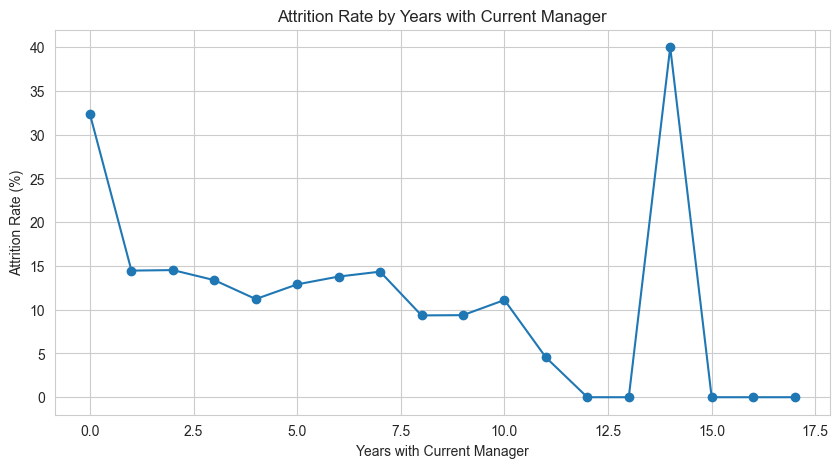

In [60]:
manager_attrition = (
    df.groupby("YearsWithCurrManager")["Attrition"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .round(2)
)

manager_attrition.plot(marker="o", figsize=(10,5))

plt.title("Attrition Rate by Years with Current Manager")
plt.xlabel("Years with Current Manager")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation

Employees with fewer years working with their current manager generally have higher attrition rates than those who have worked with the same manager for a longer period. Although attrition rates fluctuate at higher tenure levels with the current manager, these variations should be interpreted with caution, as some groups may contain relatively few employees.

### Business Insight

The higher attrition rate among employees who have spent fewer years with their current manager suggests that employees may be more likely to leave during the early stages of their relationship with a manager. However, years with the current manager alone does not fully explain employee attrition. Further analysis is needed to determine whether factors such as managerial support, career growth opportunities, workload, compensation, job satisfaction, or work-life balance are associated with the higher employee turnover observed among these employees.

## 6.6 Correlation Analysis

### Business Question 1

Which numerical variables have the strongest relationships with one another?

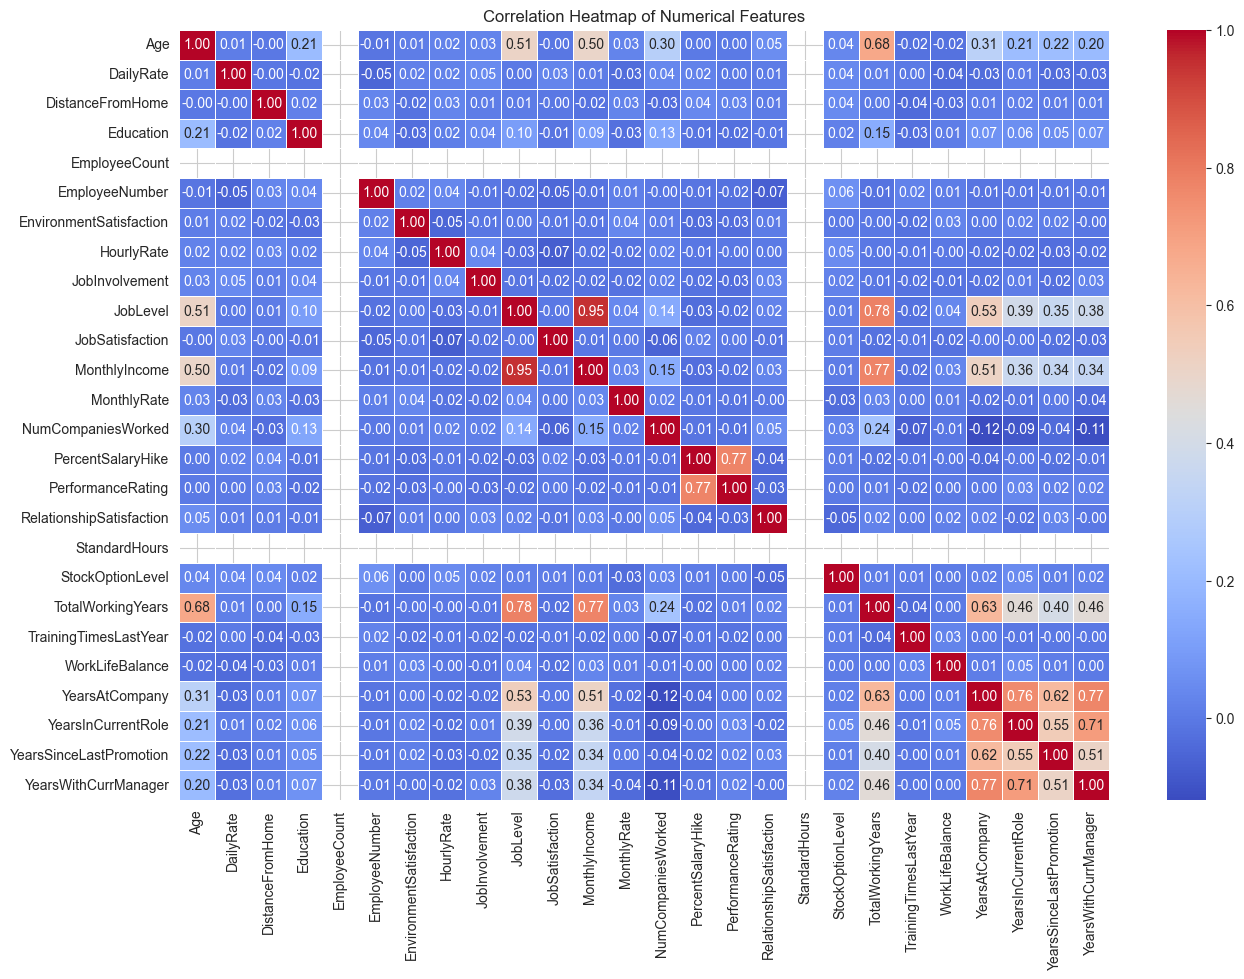

In [61]:
plt.figure(figsize=(15,10))

correlation_matrix=df.select_dtypes(include="number").corr()

sns.heatmap(
  correlation_matrix,
  annot=True,
  fmt=".2f",
  cmap="coolwarm",
  linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between numerical variables. Most feature pairs exhibit weak to moderate correlations, while a few variables related to employee experience and tenure demonstrate stronger positive relationships.

### Business Insight

The correlation analysis helps identify variables that move together and provides insights into potential relationships among employee characteristics. These relationships can support further investigation but should not be interpreted as evidence of causation.

### Business Question 2

Which numerical variables have the strongest positive correlations?

In [62]:
corr_matrix=df.select_dtypes(include="number").corr()

corr_pairs=(
  corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
  )
  .stack()
  .sort_values(ascending=False)
)

top_positive=corr_pairs.head(10)

top_positive

JobLevel            MonthlyIncome              0.950300
                    TotalWorkingYears          0.782208
PercentSalaryHike   PerformanceRating          0.773550
MonthlyIncome       TotalWorkingYears          0.772893
YearsAtCompany      YearsWithCurrManager       0.769212
                    YearsInCurrentRole         0.758754
YearsInCurrentRole  YearsWithCurrManager       0.714365
Age                 TotalWorkingYears          0.680381
TotalWorkingYears   YearsAtCompany             0.628133
YearsAtCompany      YearsSinceLastPromotion    0.618409
dtype: float64

### Observation

The strongest positive correlations are observed between **Job Level and Monthly Income (0.95)**, **Job Level and Total Working Years (0.78)**, **Monthly Income and Total Working Years (0.77)**, **Years at Company and Years with Current Manager (0.77)**, and **Years at Company and Years in Current Role (0.76)**. These results indicate strong positive relationships among employees' job level, compensation, work experience, and organizational tenure.

### Business Insight

The strong positive correlations suggest that employees with greater work experience generally progress to higher job levels and receive higher monthly incomes. Similarly, employees with longer organizational tenure tend to spend more years in their current roles and with their current managers, reflecting typical career progression within the organization. These relationships represent expected workforce patterns and provide valuable context for understanding employee development and retention.

### Business Question 3

Which numerical variables have the strongest negative correlations?

In [63]:
top_negative=corr_pairs.tail(10)

top_negative

EmployeeNumber           JobSatisfaction            -0.046247
EnvironmentSatisfaction  HourlyRate                 -0.049857
DailyRate                EmployeeNumber             -0.050990
JobSatisfaction          NumCompaniesWorked         -0.055699
NumCompaniesWorked       TrainingTimesLastYear      -0.066054
EmployeeNumber           RelationshipSatisfaction   -0.069861
HourlyRate               JobSatisfaction            -0.071335
NumCompaniesWorked       YearsInCurrentRole         -0.090754
                         YearsWithCurrManager       -0.110319
                         YearsAtCompany             -0.118421
dtype: float64

### Observation

The strongest negative correlations in the dataset are relatively weak. The highest negative correlation is observed between **Years with Current Manager** and **Years at Company (-0.12)**, while the remaining feature pairs exhibit only very weak negative relationships.

### Business Insight

The absence of strong negative correlations suggests that decreases in one numerical variable are not consistently associated with increases in another. Overall, the numerical features appear to be largely independent of one another, indicating that employee characteristics are influenced by multiple factors rather than strong inverse relationships.

### Business Question 4

Correlation With Attrition

In [64]:
df["Attrition_Binary"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

In [65]:
attrition_corr = (
    df.select_dtypes(include="number")
      .corr()["Attrition_Binary"]
      .sort_values(ascending=False)
)

attrition_corr

Attrition_Binary            1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
N

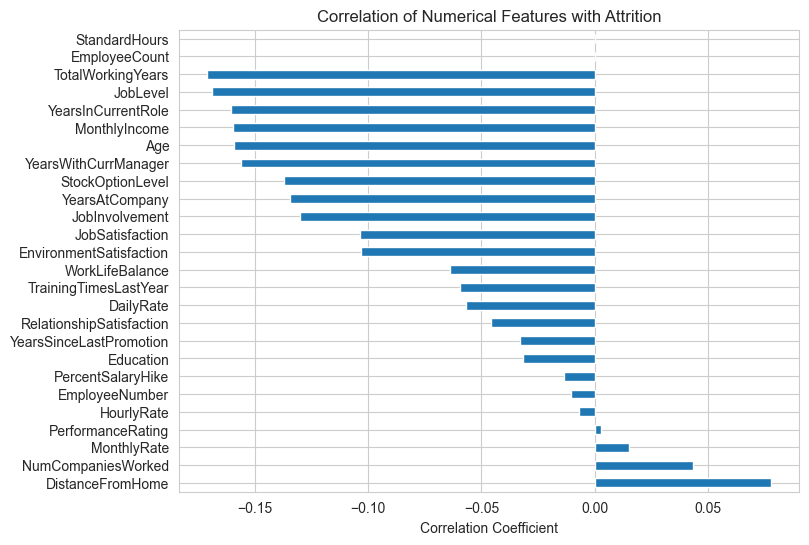

In [66]:
plt.figure(figsize=(8,6))

attrition_corr.drop("Attrition_Binary").plot(kind="barh")

plt.title("Correlation of Numerical Features with Attrition")

plt.xlabel("Correlation Coefficient")

plt.show()

### Observation

Most numerical features exhibit weak correlations with employee attrition. The strongest negative correlations are observed for **Total Working Years**, **Job Level**, **Years in Current Role**, **Monthly Income**, and **Age**, while **Distance From Home** and **Number of Companies Worked** show the strongest positive correlations. However, all correlation coefficients are relatively small in magnitude.

### Business Insight

The weak correlations indicate that no single numerical feature has a strong linear relationship with employee attrition. Instead, employee turnover is likely influenced by the combined effect of multiple factors, including employee demographics, compensation, work experience, job characteristics, and workplace satisfaction. Therefore, organizations should consider multiple factors together when developing employee retention strategies rather than relying on a single metric.

# Key Findings

1. The dataset consists of **1,470 employees** and **35 employee-related features**, providing information on demographics, job roles, compensation, experience, and employee     attrition.

2. The overall employee attrition rate is relatively low; however, specific employee groups exhibit noticeably higher turnover than others.

3. The **Sales department** has the highest employee attrition rate, with **Sales Representatives** experiencing the highest attrition among all job roles.

4. Employees who **work overtime** have a substantially higher attrition rate than employees who do not work overtime, indicating that overtime may be associated with employee turnover.

5. Younger employees, particularly those in the **18–25 age group**, experience the highest attrition rate, while employees aged **36–45** have the lowest attrition rate.

6. **Single employees** have the highest attrition rate among all marital status groups, whereas **divorced employees** exhibit the lowest attrition rate.

7. Employees with **lower monthly income**, **Stock Option Level 0**, and **Education Level 1** show higher attrition rates compared with other employee groups.

8. Employees with **shorter organizational tenure** generally experience higher attrition rates, suggesting that employee turnover is more common during the early years of employment.

9. Strong positive correlations exist between **Job Level and Monthly Income**, **Total Working Years and Monthly Income**, and other experience-related variables, reflecting expected career progression within the organization.

10. Most numerical variables exhibit **weak correlations with employee attrition**, indicating that employee turnover is influenced by multiple interacting factors rather than a single characteristic.

# Business Recommendations

1. **Review Overtime Policies**
   
   Employees who work overtime exhibit higher attrition rates. HR should evaluate workload distribution, monitor overtime practices, and encourage a healthy work-life balance to reduce employee burnout and improve retention.

2. **Strengthen Early Employee Retention Programs**
   
   Employees with shorter organizational tenure and younger employees experience higher attrition rates. The organization should strengthen onboarding programs, mentoring initiatives, and regular check-ins during the first few years of employment to improve employee retention.

3. **Evaluate Compensation and Benefits**
   
   Employees in lower monthly income groups and those without stock options demonstrate higher attrition rates. HR should periodically review compensation structures, stock option eligibility, and employee benefits to ensure competitive and equitable rewards.

4. **Enhance Career Development Opportunities**
   
   Since attrition is higher among younger employees and employees with lower education levels, the organization should provide clear career progression paths, learning opportunities, and skill development programs to support long-term employee growth.

5. **Implement Department-Specific Retention Strategies**
   
   The Sales department and Sales Representatives experience higher employee attrition than other groups. HR should conduct department-level assessments to identify role-specific challenges and implement targeted retention strategies.

6. **Provide Leadership and Managerial Support**
   
   Employees with shorter tenure under their current managers tend to exhibit higher attrition. Organizations should support managers through leadership development programs and encourage regular communication, feedback, and employee engagement.

7. **Adopt a Data-Driven Employee Retention Strategy**
   
   The correlation analysis indicates that employee attrition is influenced by multiple factors rather than a single characteristic. HR should continuously monitor employee demographics, compensation, experience, and job-related factors together to identify at-risk employees and implement proactive retention initiatives.

# Conclusion

This project analyzed the IBM HR Analytics Employee Attrition dataset to identify patterns associated with employee turnover through data cleaning, exploratory data analysis, and business-oriented interpretation.

The analysis found that employee attrition varies across departments, job roles, age groups, compensation levels, and experience. Higher attrition was observed among employees who work overtime, younger employees, employees with shorter organizational tenure, and certain job roles, particularly within the Sales department. Additionally, correlation analysis indicated that employee attrition is influenced by multiple factors rather than any single variable.

The insights and recommendations presented in this analysis can help HR teams better understand workforce trends, prioritize retention efforts, and make more informed, data-driven decisions. While this analysis identifies meaningful patterns, further investigation using predictive modeling and additional organizational data could provide deeper insights into the factors influencing employee attrition and support more targeted retention strategies.